In [1]:
import gcinfo
import pandas as pd
import matplotlib.pyplot as plt

gcinfo.search_titles(query="non-permanent", format_filter="CSV")

Estimates of non-permanent residents, quarterly, inactive
Estimates of the number of non-permanent residents by type, quarterly
Estimates of the number of non-permanent residents on July 1, by age and gender
Estimates of non-permanent residents as of July 1st, by age and sex, inactive
Job permanency (permanent and temporary) by industry, annual
Job permanency (permanent and temporary) by industry, monthly, unadjusted for seasonality
Non-permanent resident type by place of birth: Canada, provinces and territories, census metropolitan areas and census agglomerations with parts
Permanent Residents – Monthly IRCC Updates
Permanent Residents – Ad Hoc IRCC (Specialized Datasets)
Express Entry Permanent Residents – Monthly IRCC Updates
Facts and Figures 2017: Immigration Overview - Permanent Residents
Employee wages by job permanency and union coverage, annual
Immigrants to Canada, by country of last permanent residence
Specialized Research Datasets: Permanent Residents – Ad Hoc IRCC (Special

In [2]:
gcinfo.list_resources(gcinfo.search_datasets(query='title:"Estimates of the number of non-permanent residents by type, quarterly"')["results"][0])


=== Estimates of the number of non-permanent residents by type, quarterly ===
ID: f8f711fa-6b75-4178-a60c-23093c071fc8
Org: Statistics Canada | Statistique Canada
Notes: This table provides quarterly estimates of the number of non-permanent residents by type for Canada, provinces and territories.<br>...
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100121-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100121-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100121-SDMX.zip


In [3]:
df_non_permanent, df_non_permanent_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100121-eng.zip")

Using cached file: cache\17100121-eng.zip


In [4]:
gcinfo.search_titles(query="quarterly demographic estimates", format_filter="CSV")

Estimates of the components of demographic growth, annual
Population estimates, quarterly
Estimates of trusteed pension funds, quarterly
Estimates of non-permanent residents, quarterly, inactive
Quarterly estimates of business entry and exit
Estimates of the components of interprovincial migration, quarterly
Estimates of the components of international migration, quarterly
Estimates of the components of natural increase, quarterly
Annual demographic estimates by census division, age and sex, based on the Standard Geographical Classification (SGC) 2011, inactive
Annual demographic estimates by economic region, age and sex, based on the Standard Geographical Classification (SGC) 2011, inactive
Sales finance companies: quarterly statement of estimated assets and liabilities
Annual demographic estimates by census metropolitan area, age and sex, based on the Standard Geographical Classification (SGC) 2011, inactive
Estimates of the number of non-permanent residents by type, quarterly
Precoc

In [5]:
gcinfo.list_resources(gcinfo.search_datasets(query='title:"Population estimates, quarterly"')["results"][0])


=== Population estimates, quarterly ===
ID: ec690886-687d-4d59-9b1b-51311435d344
Org: Statistics Canada | Statistique Canada
Notes: Estimated number of persons by quarter of a year and by year, Canada, provinces and territories....
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100009-fra.zip
  [CSV     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/csv/17100009-eng.zip
  [XML     ] Dataset
           https://www150.statcan.gc.ca/n1/tbl/sdmx/17100009-SDMX.zip


In [6]:
df_population, df_population_meta = gcinfo.download_zip("https://www150.statcan.gc.ca/n1/tbl/csv/17100009-eng.zip")

Using cached file: cache\17100009-eng.zip


In [7]:
df_population.head()

,REF_DATE,GEO,DGUID,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1946-01,Canada,2021A000011124,Persons,249,units,0,v1,1,12188000,NaN,NaN,NaN,0
1,1946-04,Canada,2021A000011124,Persons,249,units,0,v1,1,12241000,NaN,NaN,NaN,0
2,1946-07,Canada,2021A000011124,Persons,249,units,0,v1,1,12316000,NaN,NaN,NaN,0
3,1946-10,Canada,2021A000011124,Persons,249,units,0,v1,1,12393000,NaN,NaN,NaN,0
4,1947-01,Canada,2021A000011124,Persons,249,units,0,v1,1,12450000,NaN,NaN,NaN,0


In [8]:
df_canada_population = df_population[df_population["GEO"].str.contains("Canada")][["GEO", "REF_DATE", "VALUE"]]
df_canada_population

,GEO,REF_DATE,VALUE
0,Canada,1946-01,12188000
1,Canada,1946-04,12241000
2,Canada,1946-07,12316000
3,Canada,1946-10,12393000
4,Canada,1947-01,12450000
...,...,...,...
3993,Canada,2025-04,41604555
4007,Canada,2025-07,41651653
4021,Canada,2025-10,41575585
4035,Canada,2026-01,41472081


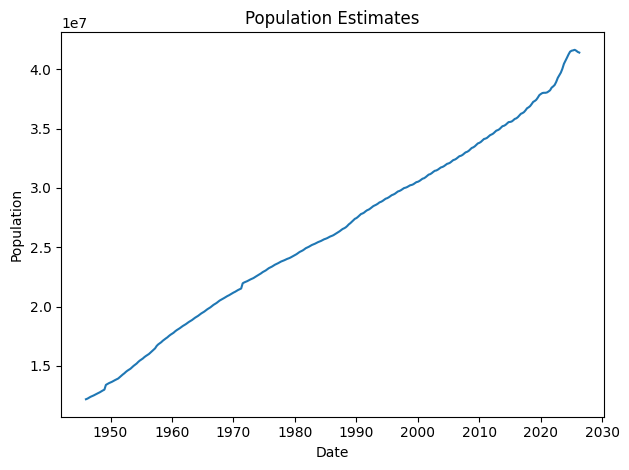

In [9]:
df_canada_population["REF_DATE"] = pd.to_datetime(df_canada_population["REF_DATE"])

plt.plot(df_canada_population["REF_DATE"], df_canada_population["VALUE"])
plt.title("Population Estimates")
plt.xlabel("Date")
plt.ylabel("Population")
plt.tight_layout()

In [10]:
df_canada_population.iloc[-1]

GEO                      Canada
REF_DATE    2026-04-01 00:00:00
VALUE                  41417056
Name: 4049, dtype: object

In [11]:
df_non_permanent.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1361855,NaN,NaN,NaN,0
1,2021-07,Canada,2021A000011124,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927591,1.2,168206,NaN,NaN,NaN,0
2,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927592,1.3,94311,NaN,NaN,NaN,0
3,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927593,1.4,1485,NaN,NaN,NaN,0
4,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927594,1.5,4094,NaN,NaN,NaN,0


In [12]:
df_canada_non_permanent = df_non_permanent[df_non_permanent["GEO"].str.contains("Canada")]
df_canada_non_permanent.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1361855,NaN,NaN,NaN,0
1,2021-07,Canada,2021A000011124,"Total, asylum claimants, protected persons and...",Persons,249,units,0,v1566927591,1.2,168206,NaN,NaN,NaN,0
2,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927592,1.3,94311,NaN,NaN,NaN,0
3,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927593,1.4,1485,NaN,NaN,NaN,0
4,2021-07,Canada,2021A000011124,"Asylum claimants, protected persons and relate...",Persons,249,units,0,v1566927594,1.5,4094,NaN,NaN,NaN,0


In [13]:
df_canada_non_permanent["REF_DATE"] = pd.to_datetime(df_canada_non_permanent["REF_DATE"])

C:\Users\D\AppData\Local\Temp\ipykernel_33444\691056638.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_canada_non_permanent["REF_DATE"] = pd.to_datetime(df_canada_non_permanent["REF_DATE"])


In [14]:
df_canada_non_permanent_total = df_canada_non_permanent[df_canada_non_permanent["Non-permanent resident types"] == "Total, non-permanent residents"]
df_canada_non_permanent_total.head()

,REF_DATE,GEO,DGUID,Non-permanent resident types,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2021-07-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1361855,NaN,NaN,NaN,0
154,2021-10-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1442604,NaN,NaN,NaN,0
308,2022-01-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1413706,NaN,NaN,NaN,0
462,2022-04-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1447790,NaN,NaN,NaN,0
616,2022-07-01,Canada,2021A000011124,"Total, non-permanent residents",Persons,249,units,0,v1566927590,1.1,1586570,NaN,NaN,NaN,0


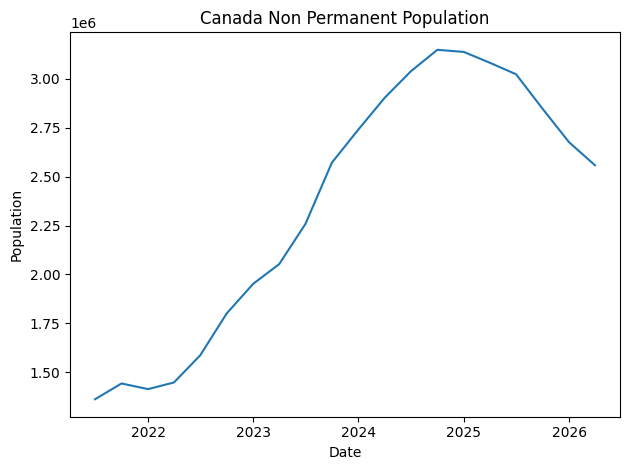

In [ ]:
plt.plot(df_canada_non_permanent_total["REF_DATE"], df_canada_non_permanent_total["VALUE"])
plt.title("Canada Non-Permanent Population")
plt.xlabel("Date")
plt.ylabel("Population")
plt.tight_layout()

In [16]:
most_recent_canada_total_non_permanent = df_canada_non_permanent_total.iloc[-1]
most_recent_canada_total_non_permanent

REF_DATE                                   2026-04-01 00:00:00
GEO                                                     Canada
DGUID                                           2021A000011124
Non-permanent resident types    Total, non-permanent residents
UOM                                                    Persons
UOM_ID                                                     249
SCALAR_FACTOR                                            units
SCALAR_ID                                                    0
VECTOR                                             v1566927590
COORDINATE                                                 1.1
VALUE                                                  2558562
STATUS                                                     NaN
SYMBOL                                                     NaN
TERMINATED                                                 NaN
DECIMALS                                                     0
Name: 2926, dtype: object

In [17]:
most_recent_canada_total_population = df_canada_population.iloc[-1]
most_recent_canada_total_population

GEO                      Canada
REF_DATE    2026-04-01 00:00:00
VALUE                  41417056
Name: 4049, dtype: object

In [18]:
import numpy as np

np.round(most_recent_canada_total_non_permanent.VALUE / most_recent_canada_total_population.VALUE * 100, 2)

np.float64(6.18)